### ***Pharmaceutical Drug Sales Analysis***

##### *Project Objective*
This project analyzes pharmaceutical sales data to identify sales trends, top-performing drug categories, regional performance, and other business patterns.
The goal is to use Python and data analysis techniques to convert raw sales data into actionable business insights.

##### *Dataset*
The dataset contains **2,106 daily pharmaceutical sales observations from 2014 to 2019**.

Sales are reported across eight ATC pharmaceutical categories:

- **M01AB** – NSAIDs: Acetic acid derivatives
- **M01AE** – NSAIDs: Propionic acid derivatives
- **N02BA** – Analgesics and antipyretics: Salicylic acid derivatives
- **N02BE** – Analgesics and antipyretics: Anilides
- **N05B** – Anxiolytics
- **N05C** – Hypnotics and sedatives
- **R03** – Drugs for obstructive airway diseases
- **R06** – Antihistamines for systemic use



##### *Tools & Technologies*

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook
- Power BI

##### *Business Questions*

1. Which countries generate the highest sales?
2. Which drug categories perform best?
3. How do sales change over time?
4. Which sales teams perform best?
5. How do product categories perform across countries?
6. Are there noticeable trends or patterns in sales?

##### *Project Workflow*

Dataset → Cleaning → Business Questions → Pandas Analysis → Charts → Dashboard → Insights → GitHub README

In [1]:
import pandas as pd
print(pd.__version__)
#Loading data
df = pd.read_csv("../data/salesdaily.csv")
df.head()


2.3.3


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


##### 1. Dataset Inspection
Before cleaning the data, we inspect its structure, dimensions, data types, and missing values. This helps to identify potential data quality issues before performing the analysis.

In [2]:
df.shape

(2106, 13)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


In [4]:
df.isnull().sum() #checks missing values in each column

datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

##### 2. Data Cleaning

The dataset is checked for duplicate records to ensure that repeated observations do not affect the analysis.

In [5]:
df.duplicated().sum()

np.int64(0)

Data Type Validation: The data types are reviewed to ensure that numerical variables are stored as numbers and that the date field can be used for time-based analysis.

In [6]:
df.dtypes

datum            object
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
Year              int64
Month             int64
Hour              int64
Weekday Name     object
dtype: object

In [7]:
df["datum"] = pd.to_datetime(df["datum"])#The datum column is converted to datetime format so that sales can be analyzed by date, month, and year.
df.dtypes

datum           datetime64[ns]
M01AB                  float64
M01AE                  float64
N02BA                  float64
N02BE                  float64
N05B                   float64
N05C                   float64
R03                    float64
R06                    float64
Year                     int64
Month                    int64
Hour                     int64
Weekday Name            object
dtype: object

Checking for Invalid Values: The numerical variables are checked for negative values to identify any potentially invalid observations before analysis.

In [8]:
df.select_dtypes(include="number").min()

M01AB       0.0
M01AE       0.0
N02BA       0.0
N02BE       0.0
N05B        0.0
N05C        0.0
R03         0.0
R06         0.0
Year     2014.0
Month       1.0
Hour      190.0
dtype: float64

Date Range Check: The date range is checked to understand the time period covered by the dataset before performing time-based analysis.

In [9]:
df["datum"].min(), df["datum"].max() 

(Timestamp('2014-01-02 00:00:00'), Timestamp('2019-10-08 00:00:00'))

##### 3. Exploratory Data Analysis

The dataset is now cleaned and validated. We next explore the sales data to identify key patterns, trends, and differences across products and time.

***Business Question 1***: Top-Performing Products? To identify the products generating the highest sales, total sales are aggregated for each product and ranked from highest to lowest.

In [10]:
product_sales = df.drop(columns=["datum","Year","Month","Hour","Weekday Name"]).sum().sort_values(ascending=False)
product_sales

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64

The total sales of all product categories are visualized to compare their overall contribution to sales.

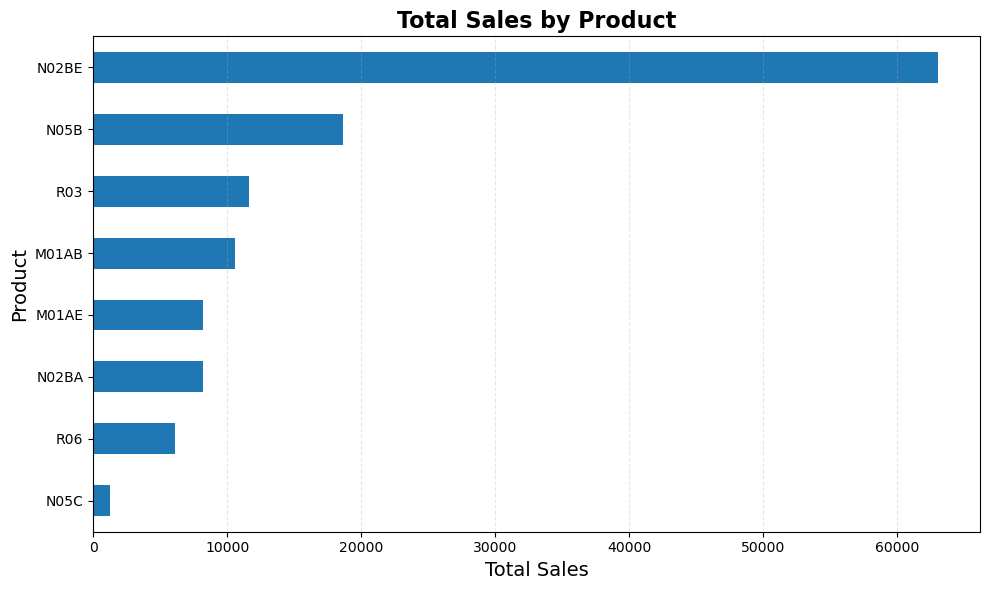

In [11]:
import matplotlib.pyplot as plt

product_sales = (
    df.drop(columns=["datum", "Year", "Month", "Hour", "Weekday Name"])
      .sum()
      .sort_values(ascending=True)
)
plt.figure(figsize=(10,6))
product_sales.plot(kind="barh")

plt.title("Total Sales by Product", fontsize=16,fontweight="bold")
plt.xlabel("Total Sales", fontsize=14)
plt.ylabel("Product",fontsize=14)

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout() #prevents labels getting cut off
plt.show()

N02BE generated the highest total sales among the products, followed by N05B and R03. N05C recorded the lowest sales. The results show a clear difference in sales performance across products, with N02BE substantially outperforming the other products.

***Business Question 2***: Sales Trends Over Time. Daily sales are aggregated across all products to identify overall sales trends and changes over the study period.

In [12]:
df["datum"].duplicated().sum()

np.int64(0)

In [13]:
daily_sales = (df.drop(columns=["Year","Month","Hour","Weekday Name","Hour"]).set_index("datum").sum(axis=1).sort_values(ascending=False))
daily_sales

datum
2016-12-30    198.950
2019-01-20    162.283
2016-12-31    151.239
2019-02-02    150.508
2019-01-27    145.365
               ...   
2019-04-18      0.000
2019-04-28      0.000
2018-04-08      0.000
2014-05-01      0.000
2015-12-19      0.000
Length: 2106, dtype: float64

Sales Trend Over Time: Daily sales are visualized using a line chart to identify overall trends, fluctuations, and changes in sales over the study period.

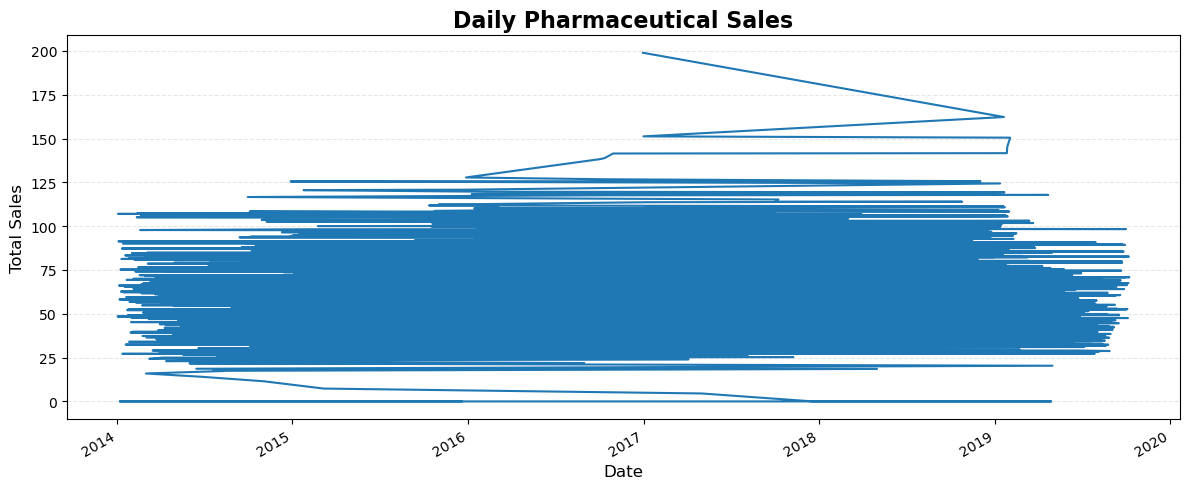

In [14]:
plt.figure(figsize=(12,5))

daily_sales.plot()

plt.title("Daily Pharmaceutical Sales", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Daily sales show substantial fluctuations throughout the study period. The highest recorded daily sales occurred on **30 December 2016 (198.95)**, followed by **20 January 2019 (162.28)** and **2 January 2019 (150.51)**. These peaks represent notable short-term increases in sales compared with the typical daily sales levels.

***Business Question 3***: Sales Performance by Year. Annual sales are aggregated to compare overall performance across different years and identify changes in sales over the years.

In [15]:
yearly_sales = (df.drop(columns=["datum","Month","Hour","Weekday Name"]).groupby("Year").sum().sum(axis=1).sort_values(ascending=False))
yearly_sales

Year
2016    25234.926000
2018    22884.561000
2015    22752.358000
2014    20238.337687
2017    19399.365667
2019    17085.955333
dtype: float64

Annual Sales Performance: Annual sales are visualized to compare overall sales performance across the years and identify changes in yearly sales levels.

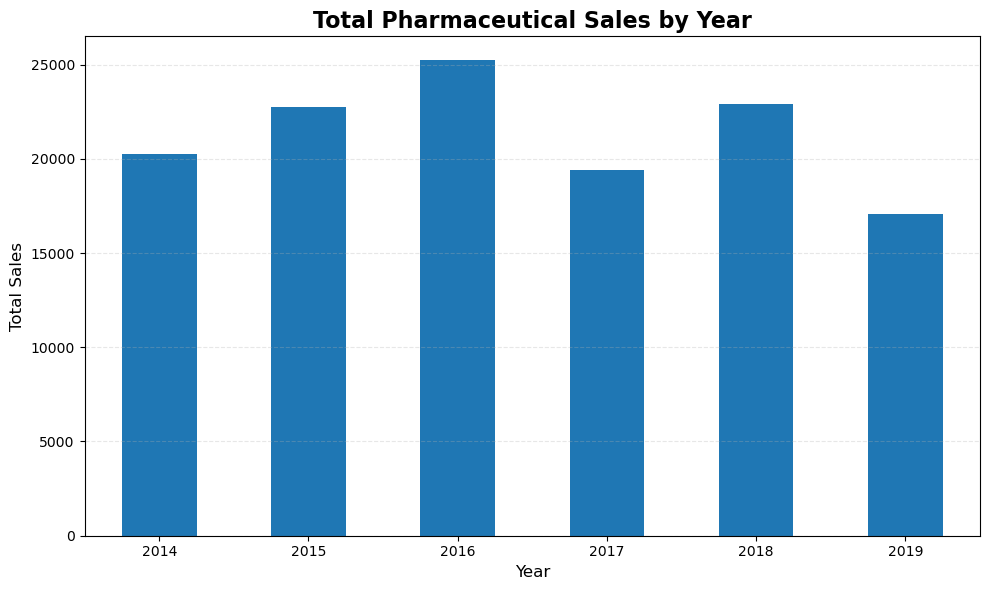

In [16]:
plt.figure(figsize=(10,6))

yearly_sales.sort_index().plot(kind="bar")
plt.title("Total Pharmaceutical Sales by Year", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Annual sales varied across the study period. Sales increased from 2014 to 2016, with **2016 recording the highest annual sales (25,234.93)**. Sales then declined in 2017 before increasing again in 2018. The lowest annual sales were recorded in **2019 (17,085.96)**. Overall, the results show fluctuations in annual sales rather than a consistent upward or downward trend.

***Business Question 4***: Sales Performance by Month. Monthly sales are aggregated across all years to identify recurring monthly patterns and determine whether certain months consistently generate higher or lower sales.

In [17]:
monthly_sales = df.drop(columns=["Year","Hour","Weekday Name","datum"]).groupby("Month").sum().sum(axis=1).sort_index()
monthly_sales

Month
1     13970.691083
2     11604.568583
3     11363.605000
4     10248.718000
5      9925.967667
6      8992.861000
7      8758.503333
8      9037.611333
9     11000.856667
10    12051.024687
11     9534.383333
12    11106.713000
dtype: float64

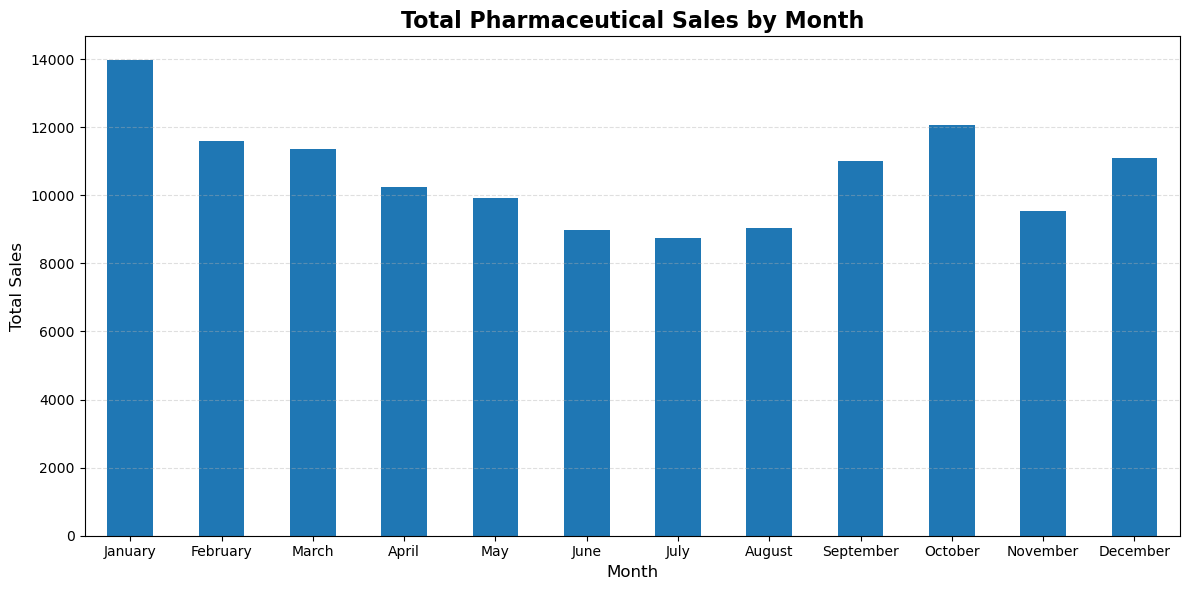

In [18]:
import calendar

plt.figure(figsize=(12,6))

monthly_sales.plot(kind="bar")

plt.title("Total Pharmaceutical Sales by Month", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(
    range(12),
    [calendar.month_name[i] for i in range(1, 13)],
    rotation=0
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Monthly sales showed noticeable variation across the year. January recorded the highest total sales (13,970.69), while July recorded the lowest (8,992.86). Sales generally declined from January to July, followed by a recovery from August to October. Sales decreased again in November before increasing in December. Overall, the pattern suggests recurring seasonal variation in monthly sales.

***Business Question 5***: Sales Performance by Day of Week. Sales are aggregated by day of the week to identify whether certain weekdays consistently show higher or lower sales levels. This will further help in sales planning.

In [19]:
weekday_sales = df.drop(columns=["Hour","Month","Year","datum"]).groupby("Weekday Name").sum().sum(axis=1).reindex([
          "Monday",
          "Tuesday",
          "Wednesday",
          "Thursday",
          "Friday",
          "Saturday",
          "Sunday"
      ])
weekday_sales

Weekday Name
Monday       18242.816667
Tuesday      18065.247000
Wednesday    17771.527500
Thursday     17212.389271
Friday       18134.491583
Saturday     19767.594417
Sunday       18401.437250
dtype: float64

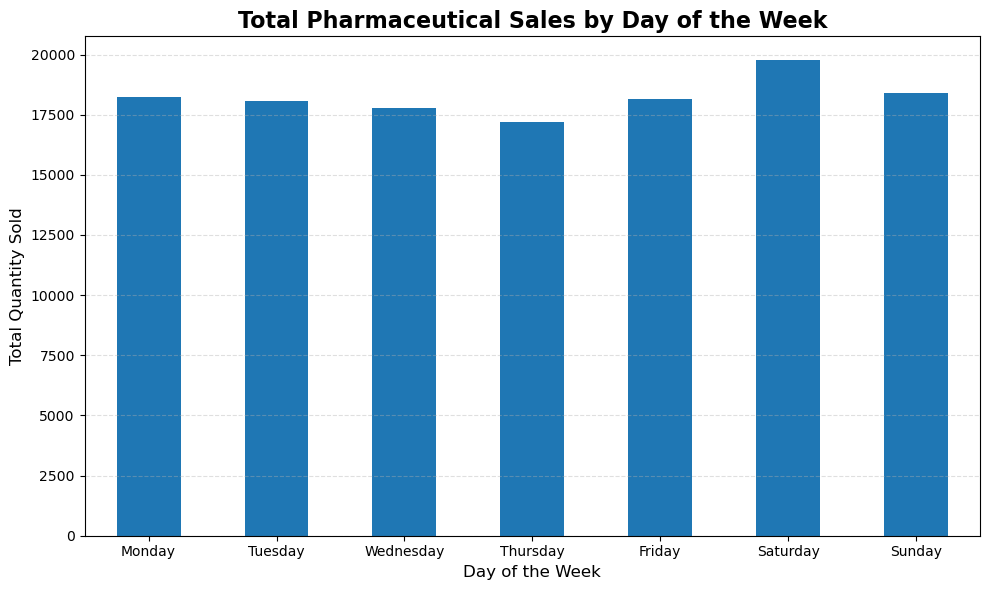

In [20]:
plt.figure(figsize=(10,6))

weekday_sales.plot(kind="bar")

plt.title("Total Pharmaceutical Sales by Day of the Week",fontsize=16,fontweight="bold")
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Total Quantity Sold", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Sales vary across the days of the week, with **Saturday recording the highest total quantity sold**, while **Thursday recorded the lowest**. Sales on Monday, Tuesday, Wednesday, Friday, and Sunday were relatively similar. Overall, the differences suggest some variation in sales across weekdays.

***Business Question 6***: Product Contribution to Total Sales. The contribution of each product to overall sales is calculated to determine how much each product contributes to the total sales volume. 

In [21]:
product_sales = df.drop(columns=["Year","Month","Hour","Weekday Name","datum"]).sum().sort_values(ascending=False)

product_contribution = ((product_sales/product_sales.sum())*100).round(2).astype(str)+ "%"
product_contribution

N02BE    49.38%
N05B     14.61%
R03        9.1%
M01AB     8.31%
M01AE     6.43%
N02BA      6.4%
R06       4.79%
N05C      0.98%
dtype: object

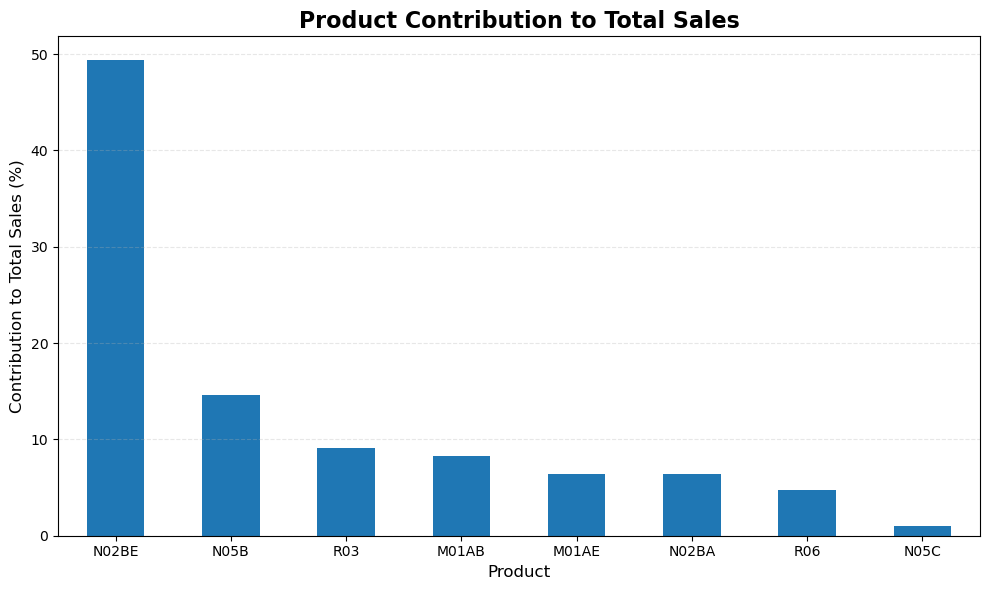

In [22]:
plt.figure(figsize=(10, 6))

product_contribution_numeric = (
    product_sales / product_sales.sum() * 100
)

product_contribution_numeric.plot(kind="bar")

plt.title("Product Contribution to Total Sales",
          fontsize=16, fontweight="bold")
plt.xlabel("Product", fontsize=12)
plt.ylabel("Contribution to Total Sales (%)", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The product contribution analysis shows that sales are highly concentrated among a small number of products. **N02BE contributes 49.38% of total sales**, accounting for almost half of the overall sales volume. N05B is the second-largest contributor at 14.61%, followed by R03 at 9.10%. In contrast, N05C contributes only 0.98% of total sales. This indicates that overall sales performance is strongly influenced by the performance of N02BE, while the remaining products contribute comparatively smaller shares.

***Business Question 7***: Product Performance by Year. Annual sales are analysed for each product to determine how product performance changes across years and whether the overall product mix remains consistent over time.

In [23]:
product_year_sales = (
    df.drop(columns=["datum", "Month", "Hour", "Weekday Name"])
      .groupby("Year")
      .sum()
)

product_year_sales

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Year,,,,,,,,
2014,1447.215000,1257.104312,1616.466500,9274.376875,4315.062500,272.625000,1255.000000,800.4875
2015,1895.620000,1496.603000,1608.630000,11923.225000,2965.000000,159.000000,1721.250000,983.0300
2016,2107.285000,1589.441000,1655.216667,13335.580000,3138.333333,207.000000,2137.000000,1065.0700
2017,1846.617083,1387.298333,1288.295833,9258.804833,2555.541667,180.333333,1893.614583,988.8600
2018,1786.930000,1389.656000,1123.800000,11230.925000,3266.200000,235.000000,2655.250000,1196.8000
2019,1517.270000,1084.516000,879.800000,7982.491000,2405.600000,196.000000,1946.708333,1073.5700


<Figure size 1400x800 with 0 Axes>

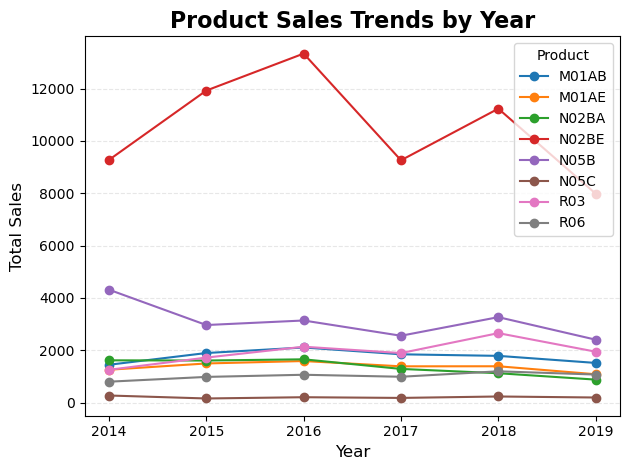

In [24]:
plt.figure(figsize=(14, 8))

product_year_sales.plot(marker="o")

plt.title("Product Sales Trends by Year", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Product")
plt.tight_layout()
plt.show()

 Product sales varied across the study period, with N02BE consistently recording the highest annual sales and reaching its maximum in 2016. N05B remained the second-highest-selling product across most years. Several products showed fluctuations over time, with increases followed by declines in later years. Overall, the product mix was dominated by N02BE, while the remaining products contributed substantially smaller sales volumes.

***Business Question 8***: Sales Performance by Hour. Hourly sales are aggregated across all products to identify which hours of the day record higher or lower sales activity and to determine whether sales show any clear hourly pattern.

In [25]:
hourly_df = pd.read_csv("../data/saleshourly.csv")
hourly_df.head()


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014 8:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
1,1/2/2014 9:00,0.0,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
2,1/2/2014 10:00,0.0,0.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday
3,1/2/2014 11:00,0.0,0.00,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday
4,1/2/2014 12:00,0.0,2.00,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday


In [26]:
hourly_sales = (
    hourly_df
    .drop(columns=["datum", "Year", "Month", "Weekday Name"])
    .groupby(hourly_df["Hour"])
    .sum()
    .sum(axis=1)
    .sort_index()
)

hourly_sales

Hour
0         0.000000
1      2105.000000
2      4210.000000
3      6315.000000
4      8420.000000
5     10525.000000
6     12630.000000
7     15307.567500
8     22888.749167
9     27048.519667
10    30651.414042
11    33899.956083
12    35818.213542
13    36951.369188
14    38264.673375
15    39776.917917
16    41547.946875
17    44056.304333
18    47979.576917
19    51335.757917
20    53311.060958
21    50808.472458
22    46470.420417
23    48415.583333
dtype: float64

Hourly Sales Trend: Total sales are visualized across the 24-hour period to identify peak and low-sales hours and examine the overall pattern of sales activity throughout the day.

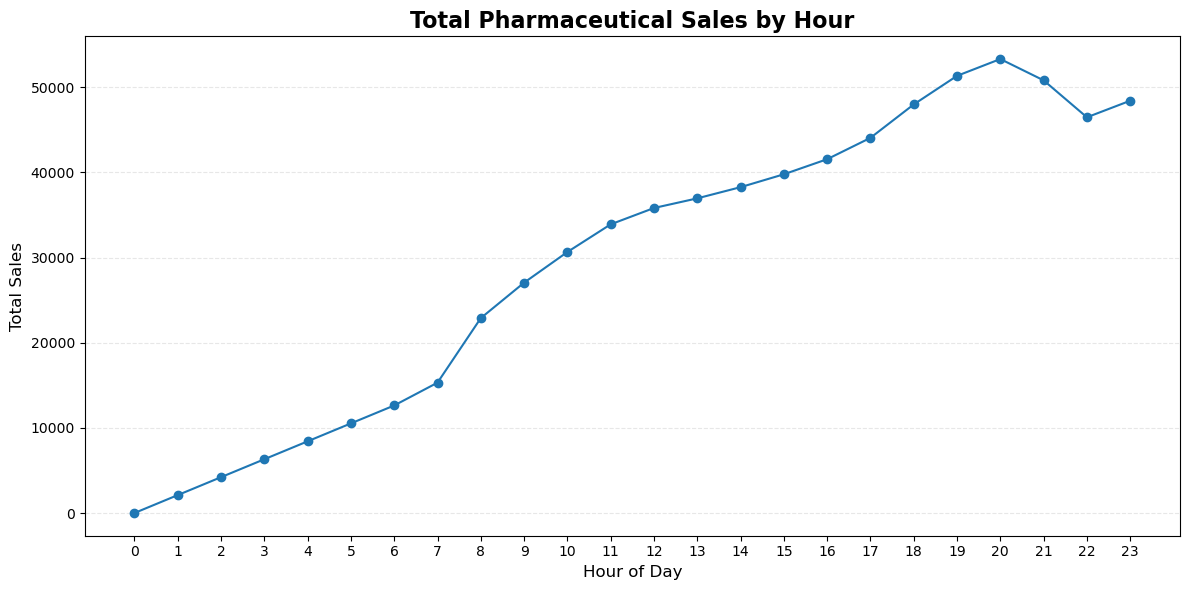

In [27]:
plt.figure(figsize=(12, 6))

hourly_sales.plot(marker="o")

plt.title("Total Pharmaceutical Sales by Hour", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(range(24))
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Hourly sales show a clear time-of-day pattern. Sales increase steadily from 00:00 through the afternoon and reach the highest level at 20:00, with total sales of approximately 53,311. Sales then decline during 21:00 and 22:00 before increasing slightly at 23:00. Overall, sales activity is substantially higher during the later hours of the day compared with the early morning hours.

***Business Question 9***: Monthly Sales Trend Over Time. Monthly sales are aggregated by year and month to examine how sales change throughout the study period. This analysis helps identify month-to-month fluctuations, sustained increases or decreases, and potential seasonal patterns in pharmaceutical sales.

In [28]:
monthly_trend = (df.drop(columns=["Hour","Weekday Name","datum"]).groupby(["Year","Month"]).sum().sum(axis=1).reset_index().rename(columns={0:"Total Sales"}))
monthly_trend

,Year,Month,Total Sales
0,2014,1,1801.110000
1,2014,2,1974.470000
2,2014,3,1606.720000
3,2014,4,1423.925000
4,2014,5,1506.303000
...,...,...,...
65,2019,6,1482.407000
66,2019,7,1488.816000
67,2019,8,1377.779000
68,2019,9,1824.803667


In [29]:
monthly_pivot = monthly_trend.pivot(
    index="Month",
    columns="Year",
    values="Total Sales"
)

monthly_pivot

Year,2014,2015,2016,2017,2018,2019
Month,,,,,,
1,1801.110000,2157.749,2451.376000,2699.597083,1985.701,2875.158000
2,1974.470000,1831.532,2232.400000,1447.471583,2174.498,1944.197000
3,1606.720000,1949.076,2235.169000,1376.855000,2156.847,2038.938000
4,1423.925000,1723.885,2147.573000,1341.800000,1894.730,1716.805000
5,1506.303000,1644.577,1957.021000,1369.485000,1650.130,1798.451667
6,1390.205000,1674.233,1724.731000,1306.936000,1414.349,1482.407000
7,1332.370000,1523.048,1599.639333,1251.151000,1563.479,1488.816000
8,1452.520000,1659.597,1633.388333,1302.420000,1611.907,1377.779000
9,1804.594000,1679.367,2049.877000,1660.841000,1981.374,1824.803667


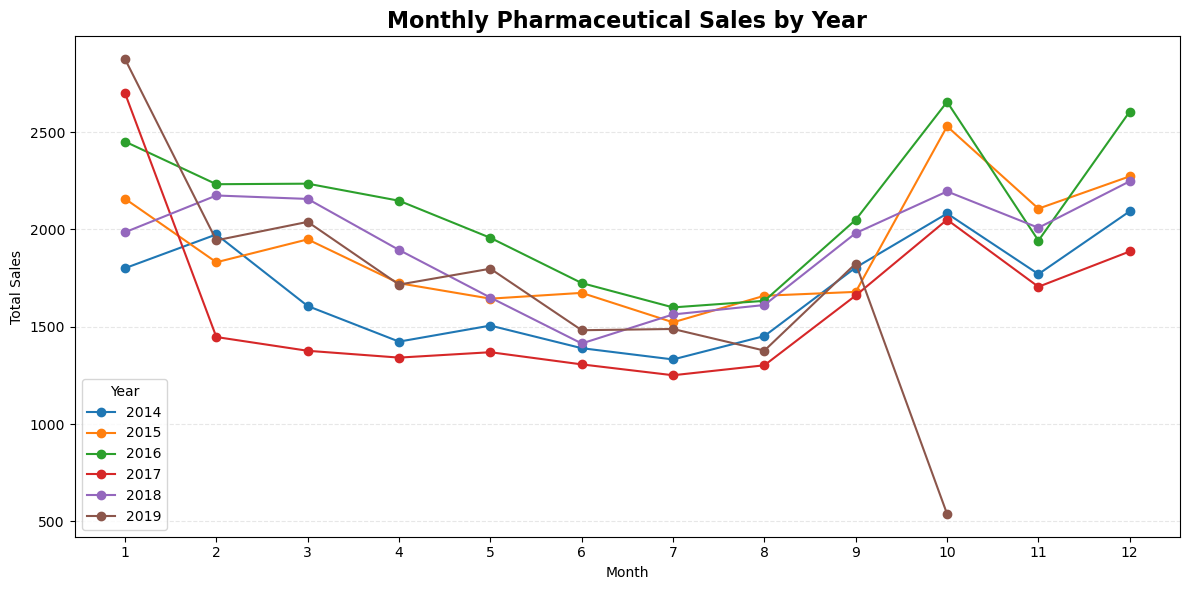

In [30]:
plt.figure(figsize=(12, 6))

for year in monthly_pivot.columns:
    plt.plot(
        monthly_pivot.index,
        monthly_pivot[year],
        marker="o",
        label=str(year)
    )

plt.title("Monthly Pharmaceutical Sales by Year", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Year")

plt.tight_layout()
plt.show()

Monthly sales show noticeable fluctuations within each year rather than a consistent month-to-month pattern. Sales are generally higher during the beginning and later parts of the year, while several years show lower sales during the middle of the year, particularly around June and July. The highest monthly sales are observed in January 2019 and October 2016, indicating substantial month-to-month variation across years. A similar increase in sales is also visible around September and October in several years, suggesting a possible recurring seasonal pattern. However, 2019 contains data only up to October, so the lower October value should be interpreted cautiously and may reflect incomplete data rather than a true decline in sales.

***Business Question 10***: Sales Distribution and Outlier Analysis. The distribution of sales is analysed to understand the overall spread and variability of sales values and to identify unusually high or low sales observations. Histograms and box plots are used to visualise the distribution and detect potential outliers. This analysis provides additional insight into the consistency of sales and helps determine whether extreme observations may influence subsequent statistical analyses.

In [31]:
df.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='object')

In [32]:
sales_columns = [
    "M01AB", "M01AE", "N02BA", "N02BE",
    "N05B", "N05C", "R03", "R06"
]

daily_sales = df.groupby("datum")[sales_columns].sum().sum(axis=1)

daily_sales.head()

datum
2014-01-02     48.47
2014-01-03    107.00
2014-01-04     91.35
2014-01-05     66.10
2014-01-06     58.20
dtype: float64

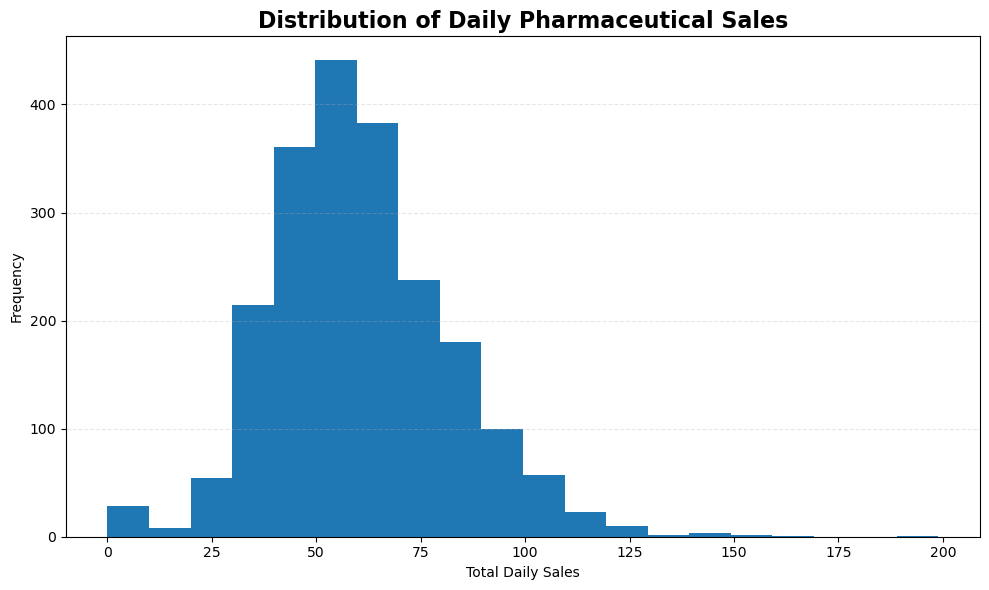

In [33]:
plt.figure(figsize=(10, 6))

plt.hist(daily_sales, bins=20)

plt.title("Distribution of Daily Pharmaceutical Sales", fontsize=16, fontweight="bold")
plt.xlabel("Total Daily Sales")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The distribution of total daily pharmaceutical sales is examined using a histogram to assess the spread, concentration, and overall shape of the sales data. The distribution is concentrated mainly around the middle range of daily sales, with a longer tail extending toward higher sales values. This indicates right-skewness and suggests the presence of some unusually high daily sales observations.

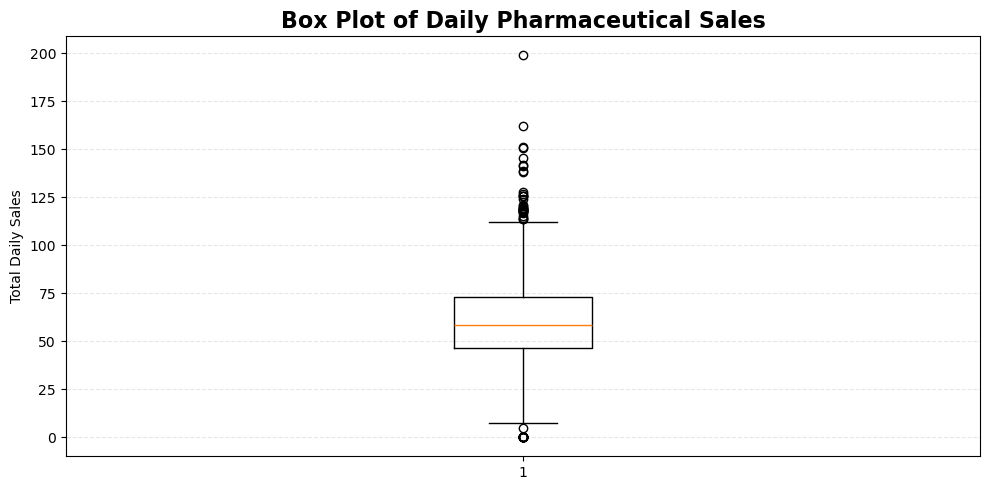

In [34]:
plt.figure(figsize=(10, 5))

plt.boxplot(daily_sales)

plt.title("Box Plot of Daily Pharmaceutical Sales", fontsize=16, fontweight="bold")
plt.ylabel("Total Daily Sales")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

A box plot is used to identify the central tendency, variability, and potential outliers in daily pharmaceutical sales. The median daily sales are approximately 58 units, while the middle 50% of observations fall within a relatively narrow range. Several observations occur above the upper whisker, indicating potential high-sales outliers, along with a small number of low-sales observations. 

##### 4. Statistical Analysis

Descriptive Statistics: Descriptive statistics are calculated to summarise the central tendency, variability, and range of pharmaceutical sales. Measures including **mean**, **median**, **standard deviation**, **minimum**, **maximum**, and **quartiles** are used to provide a numerical overview of the sales data before conducting further statistical tests.

In [35]:
descriptive_stats = df[sales_columns].describe().T
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
M01AB,2106.0,5.033683,2.737579,0.0,3.00,4.99,6.670,17.340000
M01AE,2106.0,3.895830,2.133337,0.0,2.34,3.67,5.138,14.463000
N02BA,2106.0,3.880441,2.384010,0.0,2.00,3.50,5.200,16.000000
N02BE,2106.0,29.917095,15.590966,0.0,19.00,26.90,38.300,161.000000
N05B,2106.0,8.853627,5.605605,0.0,5.00,8.00,12.000,54.833333
N05C,2106.0,0.593522,1.092988,0.0,0.00,0.00,1.000,9.000000
R03,2106.0,5.512262,6.428736,0.0,1.00,4.00,8.000,45.000000
R06,2106.0,2.900198,2.415816,0.0,1.00,2.00,4.000,15.000000


***Business Question 11***: Correlation Between Product Sales: The correlation between product sales is analysed to determine whether sales of different pharmaceutical products tend to move together. Correlation coefficients are calculated for all product pairs to identify positive or negative relationships and assess the strength of association between product sales.

In [36]:
correlation_matrix = df[sales_columns].corr().round(2)

correlation_matrix

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
M01AB,1.00,0.19,0.15,0.18,0.03,0.02,0.08,0.09
M01AE,0.19,1.00,0.17,0.29,0.06,0.03,0.09,0.03
N02BA,0.15,0.17,1.00,0.21,0.18,0.06,0.04,-0.03
N02BE,0.18,0.29,0.21,1.00,0.07,0.00,0.22,-0.13
N05B,0.03,0.06,0.18,0.07,1.00,0.25,0.04,-0.06
N05C,0.02,0.03,0.06,0.00,0.25,1.00,0.01,-0.00
R03,0.08,0.09,0.04,0.22,0.04,0.01,1.00,0.01
R06,0.09,0.03,-0.03,-0.13,-0.06,-0.00,0.01,1.00


The correlation matrix shows predominantly weak relationships between product sales. The strongest positive correlation was observed between M01AE and N02BE (r = 0.29), followed by N05B and N05C (r = 0.25). The strongest negative correlation was between N02BE and R06 (r = -0.13). Overall, no strong correlations were observed, indicating that the sales of different products generally do not exhibit strong linear co-movement over the study period.

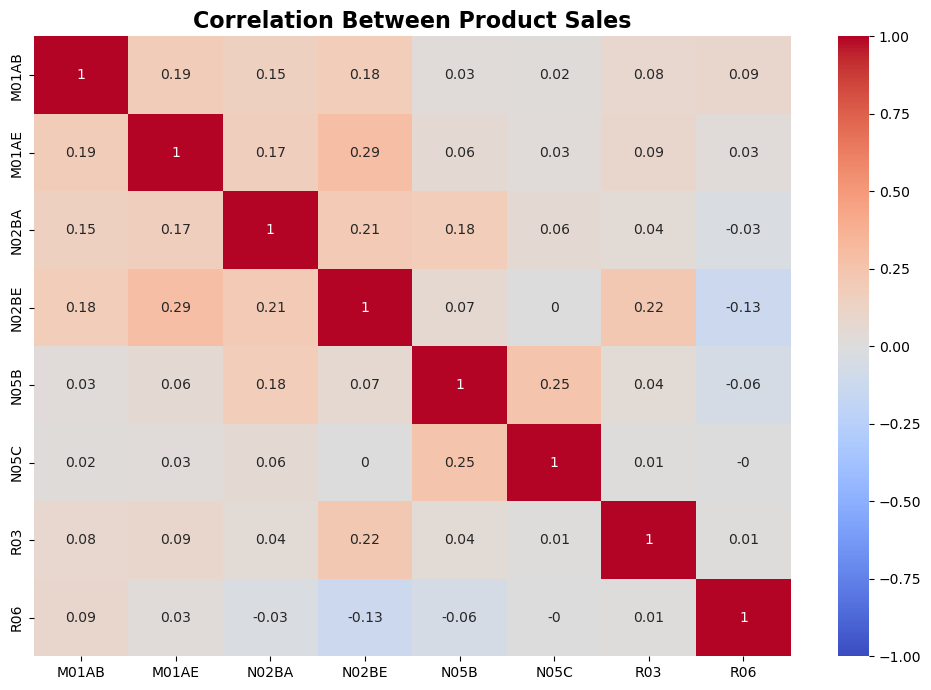

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Product Sales", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

The correlation heatmap shows the linear relationships between the sales of different pharmaceutical products. Correlation coefficients range from -1 to +1, where positive values indicate that two products tend to increase together, while negative values indicate an inverse relationship.

The strongest positive correlation between different products is observed between M01AE and N02BE (r = 0.29), followed by N05B and N05C (r = 0.25) and N02BE and R03 (r = 0.22). However, these correlations are still weak.


***Business Question 12***: Difference in Average Sales Between Products. A one-way Analysis of Variance (ANOVA) is performed to determine whether the mean sales quantities differ significantly among the pharmaceutical products. The test compares the average sales of all products simultaneously and determines whether the observed differences in their mean sales are statistically significant.

In [38]:
from scipy.stats import f_oneway

groups = [df[col].dropna() for col in sales_columns]

anova_result = f_oneway(*groups)
anova_result

F_onewayResult(statistic=np.float64(4305.75189981918), pvalue=np.float64(0.0))

The one-way ANOVA produced an F-statistic of approximately 4305.75 with a p-value close to 0. The extremely small p-value indicates that the differences in mean sales among the pharmaceutical products are statistically significant. Therefore, the null hypothesis that all products have equal mean sales is rejected. However, ANOVA alone does not identify which specific products differ from each other; a post-hoc test would be required for pairwise comparisons.

***Business Question 13***: Post-Hoc Comparison of Product Sales

Since the one-way ANOVA indicated a statistically significant difference in mean sales among the pharmaceutical products, a Tukey HSD (Honestly Significant Difference) post-hoc test is performed to identify which specific pairs of products differ significantly in their average sales.

The test compares the mean sales of every pair of products while controlling for multiple comparisons.

In [39]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd 


sales_data = df[sales_columns].melt(     # Combine all product sales into one column
    var_name="Product",
    value_name="Sales"
)


tukey_result = pairwise_tukeyhsd(       # Perform Tukey HSD test
    endog=sales_data["Sales"],
    groups=sales_data["Product"],
    alpha=0.05
)

print(tukey_result)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
 M01AB  M01AE  -1.1379    0.0  -1.7474  -0.5283   True
 M01AB  N02BA  -1.1532    0.0  -1.7628  -0.5437   True
 M01AB  N02BE  24.8834    0.0  24.2739  25.4929   True
 M01AB   N05B   3.8199    0.0   3.2104   4.4295   True
 M01AB   N05C  -4.4402    0.0  -5.0497  -3.8307   True
 M01AB    R03   0.4786 0.2511  -0.1309   1.0881  False
 M01AB    R06  -2.1335    0.0   -2.743   -1.524   True
 M01AE  N02BA  -0.0154    1.0  -0.6249   0.5941  False
 M01AE  N02BE  26.0213    0.0  25.4118  26.6308   True
 M01AE   N05B   4.9578    0.0   4.3483   5.5673   True
 M01AE   N05C  -3.3023    0.0  -3.9118  -2.6928   True
 M01AE    R03   1.6164    0.0   1.0069   2.2259   True
 M01AE    R06  -0.9956    0.0  -1.6051  -0.3861   True
 N02BA  N02BE  26.0367    0.0  25.4271  26.6462   True
 N02BA   N05B   4.9732    0.0   4.3637   5.5827   True
 N02BA   N

In [40]:
tukey_df = pd.DataFrame(
    data=tukey_result._results_table.data[1:],
    columns=tukey_result._results_table.data[0]
)

significant_pairs = tukey_df[tukey_df["reject"] == True]

significant_pairs

,group1,group2,meandiff,p-adj,lower,upper,reject
0,M01AB,M01AE,-1.1379,0.0,-1.7474,-0.5283,True
1,M01AB,N02BA,-1.1532,0.0,-1.7628,-0.5437,True
2,M01AB,N02BE,24.8834,0.0,24.2739,25.4929,True
3,M01AB,N05B,3.8199,0.0,3.2104,4.4295,True
4,M01AB,N05C,-4.4402,0.0,-5.0497,-3.8307,True
6,M01AB,R06,-2.1335,0.0,-2.7430,-1.5240,True
8,M01AE,N02BE,26.0213,0.0,25.4118,26.6308,True
9,M01AE,N05B,4.9578,0.0,4.3483,5.5673,True
10,M01AE,N05C,-3.3023,0.0,-3.9118,-2.6928,True
11,M01AE,R03,1.6164,0.0,1.0069,2.2259,True


The Tukey HSD post-hoc test shows that most pairs of pharmaceutical products have statistically significant differences in their mean sales (p < 0.05). This indicates that the significant ANOVA result is driven by differences between specific product groups.

However, a few product pairs, such as M01AB and R03 and M01AE and N02BA, do not show statistically significant differences (p > 0.05). Overall, the results indicate that product-level mean sales differ substantially across most pharmaceutical products.

***Business Question 14***: Difference in Average Daily Sales Between Years. A one-way Analysis of Variance (ANOVA) is performed to determine whether the mean daily sales differ significantly across different years. This analysis evaluates whether the variation in average daily sales observed between years is statistically significant rather than due to random variation.

In [41]:
daily_total = df[sales_columns].sum(axis=1)
year_groups = [
    daily_total[df["Year"] == year]
    for year in sorted(df["Year"].unique())
]

from scipy.stats import f_oneway

year_anova = f_oneway(*year_groups)

year_anova

F_onewayResult(statistic=np.float64(26.25969234203174), pvalue=np.float64(8.280588010388658e-26))

The one-way ANOVA produced an F-statistic of 26.26 and a p-value of approximately 8.28 × 10⁻²⁶. Since the p-value is far below the significance level of 0.05, the null hypothesis is rejected.

This indicates that the mean daily pharmaceutical sales are significantly different across the years. Therefore, the observed differences in sales between years are unlikely to be due to random variation alone.

***Business Question 15***: Post-Hoc Comparison of Yearly Sales

Since the one-way ANOVA showed a statistically significant difference in mean daily sales across the years, a Tukey HSD (Honestly Significant Difference) post-hoc test is performed to identify which specific pairs of years differ significantly in their mean daily sales.



In [42]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

year_data = pd.DataFrame({
    "Year": df["Year"],
    "Sales": daily_total
})


tukey_year = pairwise_tukeyhsd(
    endog=year_data["Sales"],
    groups=year_data["Year"],
    alpha=0.05
)

print(tukey_year)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
  2014   2015   6.7354 0.0002   2.3105  11.1602   True
  2014   2016  13.3481    0.0   8.9262  17.7699   True
  2014   2017  -2.4509  0.612  -6.8757    1.974  False
  2014   2018   7.0976 0.0001   2.6727  11.5224   True
  2014   2019   5.2043 0.0219   0.4607   9.9479   True
  2015   2016   6.6127 0.0003   2.1939  11.0314   True
  2015   2017  -9.1863    0.0 -13.6081  -4.7645   True
  2015   2018   0.3622 0.9999  -4.0596    4.784  False
  2015   2019  -1.5311 0.9412  -6.2719   3.2096  False
  2016   2017 -15.7989    0.0 -20.2177 -11.3801   True
  2016   2018  -6.2505 0.0008 -10.6692  -1.8317   True
  2016   2019  -8.1438    0.0 -12.8817  -3.4058   True
  2017   2018   9.5485    0.0   5.1267  13.9703   True
  2017   2019   7.6552 0.0001   2.9144  12.3959   True
  2018   2019  -1.8933  0.865  -6.6341   2.8474  False
----------

The Tukey HSD post-hoc test identified which specific pairs of years had statistically significant differences in mean daily pharmaceutical sales.

Significant differences were observed for most year-to-year comparisons, including 2014–2015, 2014–2016, 2014–2018, 2014–2019, 2015–2016, 2015–2017, 2016–2017, 2016–2018, 2016–2019, 2017–2018, and 2017–2019 (p < 0.05).

However, no statistically significant differences were observed between 2014–2017, 2015–2018, 2015–2019, and 2018–2019 (p > 0.05).

Overall, the Tukey HSD results confirm that the significant differences detected by ANOVA are mainly associated with specific year pairs rather than all years differing from one another.

***Business Question 16***: Linear Trend in Total Daily Sales. 
A simple linear regression analysis is performed to determine whether total daily pharmaceutical sales show a statistically significant linear trend over the study period. The analysis evaluates the relationship between time and total daily sales and determines the direction and strength of the overall trend.

In [43]:
df["datum"].duplicated().sum() #checking for multiple dates

np.int64(0)

In [44]:
df["Time"] = (df["datum"] - df["datum"].min()).dt.days
df[["datum","Time"]]

,datum,Time
0,2014-01-02,0
1,2014-01-03,1
2,2014-01-04,2
3,2014-01-05,3
4,2014-01-06,4
...,...,...
2101,2019-10-04,2101
2102,2019-10-05,2102
2103,2019-10-06,2103
2104,2019-10-07,2104


In [45]:
from scipy.stats import linregress

regression_result = linregress(
    df["Time"],
    daily_total
)

regression_result

LinregressResult(slope=np.float64(0.0008762342883030675), intercept=np.float64(59.6644223324936), rvalue=np.float64(0.024712028211428066), pvalue=np.float64(0.2569775532336883), stderr=np.float64(0.000772780822485788), intercept_stderr=np.float64(0.9392893141227744))

In [46]:
print("Slope:", regression_result.slope)
print("Intercept:", regression_result.intercept)
print("R-value:", regression_result.rvalue)
print("R-squared:", regression_result.rvalue ** 2)
print("P-value:", regression_result.pvalue)
print("Standard error:", regression_result.stderr)

Slope: 0.0008762342883030675
Intercept: 59.6644223324936
R-value: 0.024712028211428066
R-squared: 0.0006106843383224166
P-value: 0.2569775532336883
Standard error: 0.000772780822485788


The linear regression analysis produced a slope of 0.000876, an R-value of 0.0247, and an R² of 0.00061. The p-value was 0.257, which is greater than the significance level of 0.05.

Therefore, there is insufficient evidence of a statistically significant linear trend in total daily pharmaceutical sales over the study period. The very low R² indicates that time explains only approximately 0.061% of the variation in daily sales.

This suggests that daily sales fluctuations are not adequately explained by a simple linear relationship with time and are likely influenced by more complex temporal patterns.

### *Final Conclusions*

The analysis of 2,106 daily pharmaceutical sales observations from 2014 to 2019 produced five key business insights:

#### 1. Sales are highly concentrated in one pharmaceutical category
N02BE is the clear sales leader, contributing **49.38% of total sales**, almost half of the overall sales volume. N05B and R03 follow at **14.61%** and **9.10%**, respectively. This means overall business performance is strongly dependent on the performance of N02BE. 

#### 2. 2016 was the strongest year
Annual sales increased from 2014 to 2016, with **2016 recording the highest annual sales of 25,234.93**. Sales declined in 2017, recovered in 2018, and reached the lowest level in the available 2019 data at **17,085.96**. The yearly pattern therefore shows fluctuations rather than continuous growth.

#### 3. Sales show a recurring seasonal pattern
January recorded the highest total monthly sales at **13,970.69**, while July recorded the lowest at **8,992.86**. Sales generally decline from the beginning of the year toward the middle of the year before recovering later. This pattern suggests that sales planning and inventory decisions may benefit from considering seasonal demand.

#### 4. Sales activity is strongly concentrated in later hours
Hourly analysis shows sales increasing throughout the day and reaching their highest level at approximately **20:00**, with total sales of about **53,311**. Sales are substantially higher during the later hours compared with the early morning period. This provides a useful timing signal for sales and distribution planning.

#### 5. Sales differences are statistically significant, but there is no simple long-term linear trend
Statistical analysis found significant differences in average sales between pharmaceutical products and significant differences between several years. However, the linear regression showed **no statistically significant linear trend over time** (p = 0.257, R² ≈ 0.00061). This indicates that sales behaviour is more complex than a simple steady increase or decrease.

#### Overall Business Implication

The business appears to have a **highly concentrated product portfolio with strong seasonal and time-of-day variation**. Management should therefore pay particular attention to the performance and availability of N02BE, plan inventory around seasonal demand patterns, and use time-based sales patterns when planning distribution and sales activities.